# Immunogenicity tool test: Testing setttings for tools: Class1pMHC_immunogen: Tool outputs
Author: Rebecka Antonsson\
Version: 1 (26-02-2026)

# Notebook explanation
Notebook to calculate the scores of the outputs from the tool netMHCpan Immunogenicity with different settings.

Settings tested are:\
\
    immunogen_27allels_peplength8\
    immunogen_27allels_peplength9\
    immunogen_27allels_peplength10\
    immunogen_27allels_peplength11\
    immunogen_27allels_peplength12\
    immunogen_27allels_peplength13\
    immunogen_27allels_peplength14


Immunogenicity score above 0 means that peptide/allele combination is more likely than not to elicit a immune response. A higher score is therefore assumed to mean more immune response.



For each setting three measurments on how good they perform will be calculated:
    1. Mean absolute rank error (MARE) for antibodies
    2. Spearman rank correlation
    3. Mean absolute rank error for the two nanobodies

1. MARE is just the absolute difference between the known rank of the antibody and the predicted rank
2. Spearman rank correlation is a statistical test that can compare two lists of ranking and tell how well they align. 1 is a perfect correlation
0 means no relation between the two variables (no correlation, random) and -1 is a perfect reversed correlation (very bad).
3. Same calculation as for 1, but separated from the rest. Here a separate ranking where the 2 nanobodies are included are performed, hence antobodies and nanobodies get a number 1 to 39 and the MARE for the nanobodies is calculated. 

In [1]:
import pandas as pd
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

In [2]:
# Load one csv file that contains the tool scores for all the different settings mentioned above
immunogen_peplength8_14 = pd.read_csv("tool_outputs/immunogen_peplength8-14_26_02_2026.csv")
# Load a seperate csv file that contain the anitbody name with an index (above file only has index). 
# This way the antibody name can be mapped and added to the data fame with the scores. It is also a good sanity check that the mapping works.
seqs_immunogen_peplength8_14 = pd.read_csv("tool_outputs/sequence_table_immunogen_peplength8-14_26_02_2026.csv")

In [3]:
immunogen_peplength8_14.head()
seqs_immunogen_peplength8_14.head()


,seq #,sequence name,sequence
0,1,BEZLOTOXUMAB,EVQLVQSGAEVKKSGESLKISCKGSGYSFTSYWIGWVRQMPGKGLE...
1,2,VISILIZUMAB,QVQLVQSGAEVKKPGASVKVSCKASGYTFISYTMHWVRQAPGQGLE...
2,3,OMALIZUMAB,EVQLVESGGGLVQPGGSLRLSCAVSGYSITSGYSWNWIRQAPGKGL...
3,4,EVOLOCUMAB,EVQLVQSGAEVKKPGASVKVSCKASGYTLTSYGISWVRQAPGQGLE...
4,5,SECUKINUMAB,EVQLVESGGGLVQPGGSLRLSCAASGFTFSNYWMNWVRQAPGKGLE...


In [4]:
# Sanity check

# print number of unique values in seq # column (should be 39)
print(immunogen_peplength8_14['seq #'].nunique())
# print number of unique valies in HLA allele column (should be 27)
print(immunogen_peplength8_14['allele'].nunique())
# Print number of rows
print(immunogen_peplength8_14.shape[0])

39
27
1594971


In [5]:
# for loop, from 1 to length of unique values in seq # column, 
# print percanage of rows that have wat is defined as a immunigenic score 
unique_seq_numbers = immunogen_peplength8_14['seq #'].unique()
for seq_number in sorted(unique_seq_numbers):
    subset = immunogen_peplength8_14[immunogen_peplength8_14['seq #'] == seq_number]
    count_immunogen = subset[subset['immunogenicity score'] > 0].shape[0]
    total_count = subset.shape[0]
    # take the count_immunogen and divide by the total number of rows in the subset, and print the result. 
    # ANd multiply with 100 to get the percantage
    print((count_immunogen/total_count)*100)

37.59052007899934
32.93650793650794
38.35263835263835
28.371161548731642
50.031746031746025
42.077922077922075
39.349489795918366
37.745740498034074
51.598173515981735
29.24847664184157
35.78042328042328
43.78737541528239
48.401826484018265
42.5888665325285
36.74388674388675
34.53473132372215
38.095238095238095
44.2792501616031
39.285714285714285
44.07431133888533
38.72870249017038
46.54594232059021
33.2010582010582
41.409691629955944
41.05590062111801
41.4486921529175
43.90084801043705
40.36697247706422
37.692823608316566
43.84010484927916
43.97116644823067
43.05106658047835
33.77221856484529
40.42132982225149
50.531286894923255
39.136212624584715
41.9397116644823
56.295399515738495
39.12768647281922


Make a new dataframe that has the Antibody as one colmn (still here called seq #, and have just numbers),
Then each column represents one of the 7 peptide lengts plus one with all of them combined. In each column you can see the calculated immunogenic score for each antibody (seq #) and each peptide setting.
THis immunogenic score is calculated by taking the number of rows (short peptide sequences) with a immunogenicity score above 0, divided by the total amount of rows. To get the percantage of small peptides that are considered immunogenetic. 

In [6]:
# get unique seq # values and unique peptide length values
unique_seq_numbers = immunogen_peplength8_14['seq #'].unique()
unique_peptide_lengths = immunogen_peplength8_14['peptide length'].unique()

# Make a dataframe with one colums as seq, with all the unique seq # values. 
# In the for loop one wolumn for each peptide length and the percent immugen will be added 
calc_rank_table = pd.DataFrame({'seq#': sorted(unique_seq_numbers)})

# for loop, from 1 to length of unique values in seq # column, 
# #print number of rows that have wat is defined as a immunigenic score 

for peptide_length in sorted(unique_peptide_lengths):
    for seq_number in sorted(unique_seq_numbers):
        # subset unique seq # and peptide length combination
        subset = immunogen_peplength8_14[(immunogen_peplength8_14['seq #'] == seq_number) & (immunogen_peplength8_14['peptide length'] == peptide_length)]
        count_immunogen = subset[subset['immunogenicity score'] > 0].shape[0]
        total_count = subset.shape[0]
        # take the count_immunogen and divide by the total number of rows in the subset, and print the result. ANd multiply with 100 to get the percantage
        percent_immunogen = (count_immunogen/total_count)*100
        # add the percent immunogen to the dataframe, with the column name as the peptide length
        calc_rank_table.loc[calc_rank_table['seq#'] == seq_number, f'peptide length {peptide_length}'] = percent_immunogen

# add a cloumn with the average percent immunogen for each seq #, and name it all_pep_lengths
calc_rank_table['all_pep_lengths'] = calc_rank_table.filter(regex='peptide length').mean(axis=1)

calc_rank_table.head()


,seq#,peptide length 8,peptide length 9,peptide length 10,peptide length 11,peptide length 12,peptide length 13,peptide length 14,all_pep_lengths
0,1,42.272727,38.812785,37.155963,36.405530,37.037037,35.348837,35.981308,37.573456
1,2,35.616438,33.944954,34.101382,32.407407,31.162791,31.775701,31.455399,32.923439
2,3,41.777778,39.732143,38.116592,38.738739,38.914027,35.909091,35.159817,38.335455
3,4,30.875576,29.629630,27.906977,29.439252,29.107981,25.943396,25.592417,28.356461
4,5,52.192982,51.101322,50.442478,49.333333,49.553571,48.878924,48.648649,50.021608


In [7]:
# Insert the correct Antibody name

# both the dataframes calc_rank_table and the seqs_immunogen_peplength8_14 have a seq # column,
# Instert the "sequence name" to the calc_rank_table, at the matching seq #
calc_rank_table = calc_rank_table.merge(seqs_immunogen_peplength8_14[['seq #', 'sequence name']], left_on='seq#', right_on='seq #', how='left')


In [8]:
# create a copy of the calc_rank_table, without the two rows with sequence name "Caplacizumab" and "Vobarilizumab"
calc_rank_table_AB = calc_rank_table[~calc_rank_table['sequence name'].isin(['Caplacizumab', 'Vobarilizumab'])]

calc_rank_table_AB.tail()

,seq#,peptide length 8,peptide length 9,peptide length 10,peptide length 11,peptide length 12,peptide length 13,peptide length 14,all_pep_lengths,seq #,sequence name
32,33,38.636364,35.616438,33.486239,31.797235,32.870370,33.023256,30.841121,33.753003,33,RITUXIMAB
33,34,43.636364,42.009132,41.743119,41.013825,37.962963,38.139535,38.317757,40.403242,34,INFLIXIMAB
34,35,47.755102,50.000000,53.497942,52.892562,50.622407,50.000000,48.953975,50.531713,35,GOLIMUMAB
35,36,40.366972,39.631336,40.277778,38.604651,36.448598,39.906103,38.679245,39.130669,36,BOCOCIZUMAB
36,37,43.891403,41.818182,42.009132,42.201835,41.474654,41.666667,40.465116,41.932427,37,ALEMTUZUMAB


In [9]:
# Make one separete df for each tool setting

# for each column from peptide length 8 to all_pep_lengths, make a new dataframe witht the sequence name, peptide column
# name the dataframe as the column with the peptide length, keep the name of the sequence column, but rename the petide colum to "percent immunogenicity"

peptide_length_8_AB = calc_rank_table_AB[['sequence name', 'peptide length 8']].rename(columns={'peptide length 8': 'percent immunogenicity'})
peptide_length_9_AB = calc_rank_table_AB[['sequence name', 'peptide length 9']].rename(columns={'peptide length 9': 'percent immunogenicity'})
peptide_length_10_AB = calc_rank_table_AB[['sequence name', 'peptide length 10']].rename(columns={'peptide length 10': 'percent immunogenicity'})
peptide_length_11_AB = calc_rank_table_AB[['sequence name', 'peptide length 11']].rename(columns={'peptide length 11': 'percent immunogenicity'})
peptide_length_12_AB = calc_rank_table_AB[['sequence name', 'peptide length 12']].rename(columns={'peptide length 12': 'percent immunogenicity'})
peptide_length_13_AB = calc_rank_table_AB[['sequence name', 'peptide length 13']].rename(columns={'peptide length 13': 'percent immunogenicity'})
peptide_length_14_AB = calc_rank_table_AB[['sequence name', 'peptide length 14']].rename(columns={'peptide length 14': 'percent immunogenicity'})
all_pep_lengths_AB = calc_rank_table_AB[['sequence name', 'all_pep_lengths']].rename(columns={'all_pep_lengths': 'percent immunogenicity'})

peptide_length_8 = calc_rank_table[['sequence name', 'peptide length 8']].rename(columns={'peptide length 8': 'percent immunogenicity'})
peptide_length_9 = calc_rank_table[['sequence name', 'peptide length 9']].rename(columns={'peptide length 9': 'percent immunogenicity'})
peptide_length_10 = calc_rank_table[['sequence name', 'peptide length 10']].rename(columns={'peptide length 10': 'percent immunogenicity'})
peptide_length_11 = calc_rank_table[['sequence name', 'peptide length 11']].rename(columns={'peptide length 11': 'percent immunogenicity'})
peptide_length_12 = calc_rank_table[['sequence name', 'peptide length 12']].rename(columns={'peptide length 12': 'percent immunogenicity'})
peptide_length_13 = calc_rank_table[['sequence name', 'peptide length 13']].rename(columns={'peptide length 13': 'percent immunogenicity'})
peptide_length_14 = calc_rank_table[['sequence name', 'peptide length 14']].rename(columns={'peptide length 14': 'percent immunogenicity'})
all_pep_lengths = calc_rank_table[['sequence name', 'all_pep_lengths']].rename(columns={'all_pep_lengths': 'percent immunogenicity'})


In [10]:
# Load the ADA rank of the antibodies

# this is used as a "correct" ranking to compare the tools ranking to
ADA_rank = {
'BEZLOTOXUMAB':1,
'VISILIZUMAB':2,
'OMALIZUMAB':3,
'EVOLOCUMAB':4,
'SECUKINUMAB':5,
'DENOSUMAB':6,
'IBALIZUMAB':7,
'OCRELIZUMAB':8,
'FREMANEZUMAB':9,
'BASILIXIMAB':10,
'PALIVIZUMAB':11,
'CANAKINUMAB':12,
'ECULIZUMAB':13,
'BRODALUMAB':14,
'MEPOLIZUMAB':15,
'GUSELKUMAB':16,
'RESLIZUMAB':17,
'ALIROCUMAB':18,
'GALCANEZUMAB':19,
'VEDOLIZUMAB':20,
'EFALIZUMAB':21,
'TILDRAKIZUMAB':22,
'USTEKINUMAB':23,
'DUPILUMAB':24,
'ERENUMAB':25,
'SARILUMAB':26,
'NATALIZUMAB':27,
'Caplacizumab':28,
'LANADELUMAB':29,
'BUROSUMAB':30,
'BENRALIZUMAB':31,
'ADALIMUMAB':32,
'IXEKIZUMAB':33,
'RITUXIMAB':34,
'INFLIXIMAB':35,
'GOLIMUMAB':36,
'Vobarilizumab':37,
'BOCOCIZUMAB':38,
'ALEMTUZUMAB':39
}

# create antoher dictionary where the two nanobdoies are removed 
ADA_rank_AB = {
'BEZLOTOXUMAB':1,
'VISILIZUMAB':2,
'OMALIZUMAB':3,
'EVOLOCUMAB':4,
'SECUKINUMAB':5,
'DENOSUMAB':6,
'IBALIZUMAB':7,
'OCRELIZUMAB':8,
'FREMANEZUMAB':9,
'BASILIXIMAB':10,
'PALIVIZUMAB':11,
'CANAKINUMAB':12,
'ECULIZUMAB':13,
'BRODALUMAB':14,
'MEPOLIZUMAB':15,
'GUSELKUMAB':16,
'RESLIZUMAB':17,
'ALIROCUMAB':18,
'GALCANEZUMAB':19,
'VEDOLIZUMAB':20,
'EFALIZUMAB':21,
'TILDRAKIZUMAB':22,
'USTEKINUMAB':23,
'DUPILUMAB':24,
'ERENUMAB':25,
'SARILUMAB':26,
'NATALIZUMAB':27,
'LANADELUMAB':28,
'BUROSUMAB':29,
'BENRALIZUMAB':30,
'ADALIMUMAB':31,
'IXEKIZUMAB':32,
'RITUXIMAB':33,
'INFLIXIMAB':34,
'GOLIMUMAB':35,
'BOCOCIZUMAB':36,
'ALEMTUZUMAB':37
}

In [11]:
# Put all dfs into a dictionary
# So it can easly be looped over.

# One for the dfs with only antibodies
all_dfs_AB = {
'Class1pMHC_immunogen_peptide_length_8_AB': peptide_length_8_AB,
'Class1pMHC_immunogen_peptide_length_9_AB': peptide_length_9_AB,
'Class1pMHC_immunogen_peptide_length_10_AB': peptide_length_10_AB, 
'Class1pMHC_immunogen_peptide_length_11_AB': peptide_length_11_AB,
'Class1pMHC_immunogen_peptide_length_12_AB': peptide_length_12_AB,
'Class1pMHC_immunogen_peptide_length_13_AB': peptide_length_13_AB,
'Class1pMHC_immunogen_peptide_length_14_AB': peptide_length_14_AB,
'Class1pMHC_immunogen_all_pep_lengths_AB': all_pep_lengths_AB
}

# One for the dfs where nanobodies also are included
all_dfs = {
'Class1pMHC_immunogen_peptide_length_8': peptide_length_8,
'Class1pMHC_immunogen_peptide_length_9': peptide_length_9,
'Class1pMHC_immunogen_peptide_length_10': peptide_length_10, 
'Class1pMHC_immunogen_peptide_length_11': peptide_length_11,
'Class1pMHC_immunogen_peptide_length_12': peptide_length_12,
'Class1pMHC_immunogen_peptide_length_13': peptide_length_13,
'Class1pMHC_immunogen_peptide_length_14': peptide_length_14,
'Class1pMHC_immunogen_all_pep_lengths': all_pep_lengths
}

Now calculate how close the two rankings are (ADA and the tools ranking). This is done by calculating MARE and spearmanr correlation.
THe df with only the antibodies are calculated first. Then only the MARE for the two nanobodies is calculated. This is then added to one dataframe with the tool settings as rows, and the 4 measurements MARE, spearmanr, Caplacizumab_MARE and Vobarilizumab_MARE.

In [12]:
# Add the ADA_rank_AB to the AB dataframes, map them by the antibody name
for df in all_dfs_AB.values():
    df['ADA_rank'] = df['sequence name'].map(ADA_rank_AB)

# Rank the percent immunogenicity scores from 1 to 37
for df in all_dfs_AB.values():
    df['ranked_by_tool'] = df['percent immunogenicity'].rank(ascending=True, method='average')

# Add a column called MARE, for each row add the value for the absolute difference between the ranked_by_tool and ADA_rank
for df in all_dfs_AB.values():
    df['MARE'] = (df['ranked_by_tool'] - df['ADA_rank']).abs()

In [13]:
# DO the same for the dfs with nanobodies

# Add the ADA_rank to the dataframes, map them by the antibody name
for df in all_dfs.values():
    df['ADA_rank'] = df['sequence name'].map(ADA_rank)

# Rank the percent immunogenicity scores from 1 to 37
for df in all_dfs.values():
    df['ranked_by_tool'] = df['percent immunogenicity'].rank(ascending=True, method='average')

# Add a column called MARE, for each row add the value for the absolute difference between the ranked_by_tool and ADA_rank
for df in all_dfs.values():
    df['MARE'] = (df['ranked_by_tool'] - df['ADA_rank'])



In [14]:
# Create a new dataframe with the name of the dataframe as a row, the sum MARE, nanobody mean MARE and the spearman rank correlation
ranked_score_table = pd.DataFrame({
    # give it the same keys as in the all_dfs dictionary
    "dataframe": list(all_dfs_AB.keys()),
    'sum_MARE': [df['MARE'].sum() for df in all_dfs_AB.values()],
    "spearmanr": [spearmanr(df['ranked_by_tool'], df['ADA_rank']).correlation for df in all_dfs_AB.values()],
    "spearmanr_pval": [spearmanr(df['ranked_by_tool'], df['ADA_rank']).pvalue for df in all_dfs_AB.values()],
    'Caplacizumab_MARE': [df.loc[df['sequence name'] == 'Caplacizumab', 'MARE'].values[0] for df in all_dfs.values()],
    'Vobarilizumab_MARE': [df.loc[df['sequence name'] == 'Vobarilizumab', 'MARE'].values[0] for df in all_dfs.values()]
    })



# export the ranked_score_table to csv
ranked_score_table.to_csv("ranked_score_table.csv", index=False) 

ranked_score_table

,dataframe,sum_MARE,spearmanr,spearmanr_pval,Caplacizumab_MARE,Vobarilizumab_MARE
0,Class1pMHC_immunogen_peptide_length_8_AB,429.0,0.086658,0.610061,10.0,-22.0
1,Class1pMHC_immunogen_peptide_length_9_AB,402.0,0.151740,0.369973,11.0,-20.0
2,Class1pMHC_immunogen_peptide_length_10_AB,401.0,0.198684,0.238452,10.0,-17.0
3,Class1pMHC_immunogen_peptide_length_11_AB,390.0,0.195128,0.247132,11.0,-21.0
4,Class1pMHC_immunogen_peptide_length_12_AB,399.0,0.181495,0.282349,11.0,-18.0
5,Class1pMHC_immunogen_peptide_length_13_AB,358.0,0.321005,0.052722,11.0,-23.0
6,Class1pMHC_immunogen_peptide_length_14_AB,358.0,0.329303,0.046567,11.0,-28.0
7,Class1pMHC_immunogen_all_pep_lengths_AB,388.0,0.242295,0.148495,11.0,-22.0


Text(0.5, 1.0, 'Class1pMHC Immunogenicity')

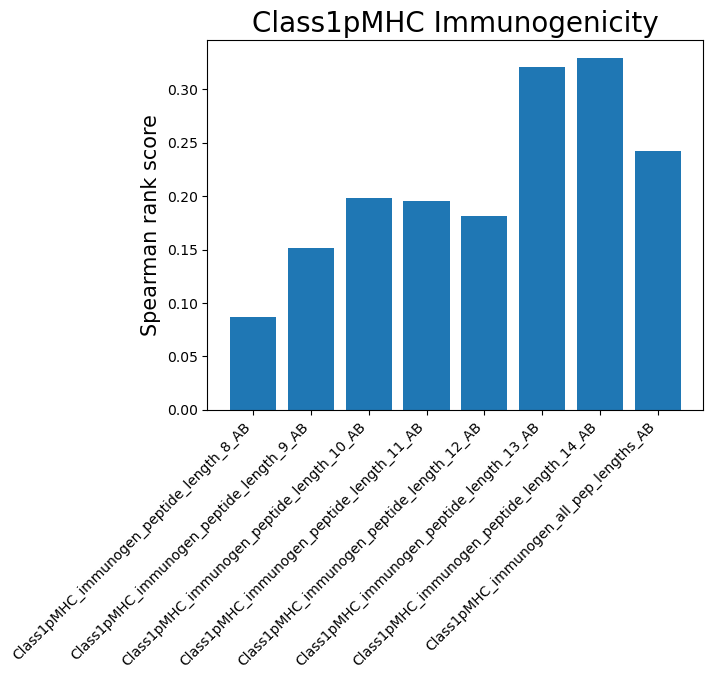

In [16]:
    # plot spearman rank score for each setting
plt.bar(ranked_score_table['dataframe'], ranked_score_table['spearmanr'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Spearman rank score', size=15)
plt.title("Class1pMHC Immunogenicity", size=20)